In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
import datetime

import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import array_to_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D
from keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

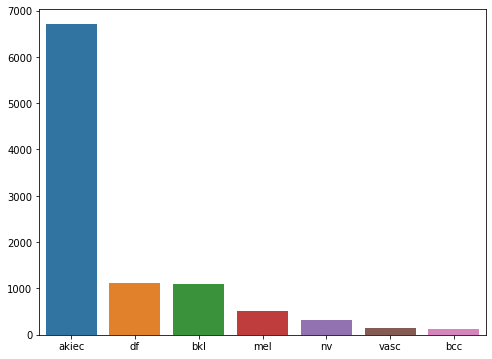

In [ ]:
'''
7 KINDS OF CLASSES PRESENT HERE WHICH ARE TO BE CLASSIFIED

0: nv - Melanocytic nevi
1: mel - Melanoma
2: bkl - Benign keratosis-like lesions
3: bcc - Basal cell carcinoma
4: akiec - Actinic keratoses and intraepithelial carcinoma / Bowen's disease
5: vasc - Vascular lesions
6: df - Dermatofibroma
'''


raw_data = pd.read_csv('/content/drive/MyDrive/Minor data/CSV/hmnist_28_28_RGB.csv')
raw_data = raw_data.sample(frac = 1)
data = raw_data.iloc[:,:-1]
labels = raw_data.iloc[:,-1:]

type_cancer = ['akiec','df','bkl','mel','nv','vasc','bcc']
counts = list(labels.value_counts())
plt.figure(figsize = (8,6))
sns.barplot(x = type_cancer, y = counts)

In [ ]:
raw_data = pd.read_csv('/content/drive/MyDrive/Minor data/CSV/hmnist_28_28_RGB.csv')
raw_data = raw_data.sort_values('label')
raw_data = raw_data.reset_index()

index0 = raw_data[raw_data['label'] == 0].index.values
index1 = raw_data[raw_data['label'] == 1].index.values
index2 = raw_data[raw_data['label'] == 2].index.values
index3 = raw_data[raw_data['label'] == 3].index.values
index5 = raw_data[raw_data['label'] == 5].index.values
index6 = raw_data[raw_data['label'] == 6].index.values

df_index0 = raw_data.iloc[int(min(index0)):int(max(index0)+1)]
df_index1 = raw_data.iloc[int(min(index1)):int(max(index1)+1)]
df_index2 = raw_data.iloc[int(min(index2)):int(max(index2)+1)]
df_index3 = raw_data.iloc[int(min(index3)):int(max(index3)+1)]
df_index5 = raw_data.iloc[int(min(index5)):int(max(index5)+1)]
df_index6 = raw_data.iloc[int(min(index6)):int(max(index6)+1)]


df_index0 = df_index0.append([df_index0]*17, ignore_index = True)
df_index1 = df_index1.append([df_index1]*15, ignore_index = True)
df_index2 = df_index2.append([df_index2]*5, ignore_index = True)
df_index3 = df_index3.append([df_index3]*52, ignore_index = True)
df_index5 = df_index5.append([df_index5]*45, ignore_index = True)
df_index6 = df_index6.append([df_index6]*5, ignore_index = True)

frames = [raw_data, df_index0, df_index1, df_index2, df_index3, df_index5, df_index6]

final_data = pd.concat(frames)
final_data.drop('index', inplace = True, axis = 1)
final_data = final_data.sample(frac = 1)
data = final_data.iloc[:,:-1]
labels = final_data.iloc[:,-1:]

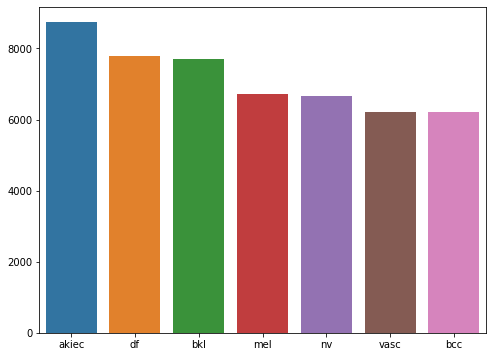

In [ ]:
type_cancer = ['akiec','df','bkl','mel','nv','vasc','bcc']
counts = list(labels.value_counts())
plt.figure(figsize = (8,6))
sns.barplot(x = type_cancer, y = counts)

In [ ]:
X = np.array(data)
Y = np.array(labels)

# reshaping the data

X = X.reshape(-1,28,28,3)

print("SHAPE OF X IS: ", X.shape)
print("SHAPE OF Y IS: ", Y.shape)

SHAPE OF X IS:  (50024, 28, 28, 3)
SHAPE OF Y IS:  (50024, 1)


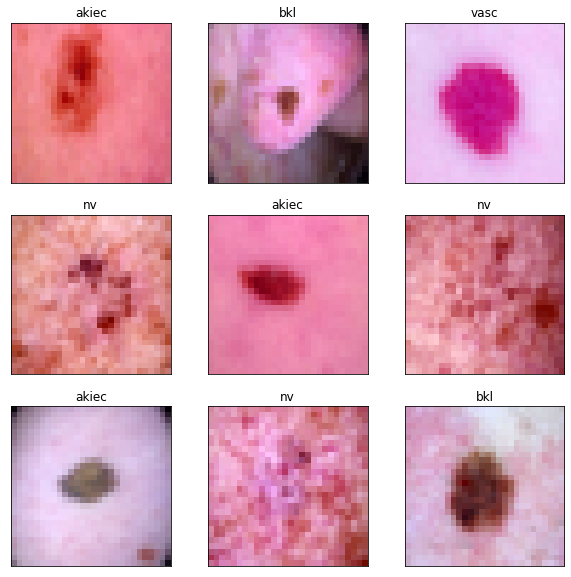

In [ ]:
'''
nv - Melanocytic nevi
mel - Melanoma
bkl - Benign keratosis-like lesions
bcc - Basal cell carcinoma
akiec - Actinic keratoses and intraepithelial carcinoma / Bowen's disease
vasc - Vascular lesions
df - Dermatofibroma
'''

def visualisePlots(X,Y, rows, columns):
    class_dicts = {
        0: 'nv',
        1: 'mel',
        2: 'bkl',
        3: 'bcc',
        4: 'akiec',
        5: 'vasc',
        6: 'df', 
    }
    
    data = []
    target = []

    for i in range(rows*columns):
        data.append(X[i])
        target.append(Y[i])

    width = 10
    height = 10
    fig = plt.figure(figsize=(10,10))
    for i in range(columns*rows):
        temp_img = array_to_img(data[i])
        fig.add_subplot(rows, columns, i+1)
        plt.imshow(temp_img)
        plt.xticks([])
        plt.yticks([])
        plt.title(str(class_dicts[target[i][0]]))
    plt.show()
    
# using the above function

visualisePlots(X,Y, 3,3)

### CREAING THE MODEL, TRAINING THE MODEL

In [ ]:
'''
SPLITTING THE DATA INTO TRAIN AND THE TESTING DATA
SPLIT THE DATA INTO 20% OF TESTING DATA AND 80% OF THE TRAINING DATA
ALSO THE DATA IS STANDARDISED BEFORE THE SPLIT OF THE DATA

AFTER THE SPLIT OF THE DATA, IT IS ALSO BEEN AUGMENTATED WITH THE IMAGEDATAGENERATOR 
THE AUGMENTED DATA IS THEN TRAINED
'''

#X = (X-np.mean(X))/np.std(X)
X = X/255.0
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 10,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  horizontal_flip = True,
                                  vertical_flip = True,
                                  fill_mode = 'nearest')
train_datagen.fit(X_train)

test_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen.fit(X_test)

train_data = train_datagen.flow(X_train, Y_train, batch_size = 64)
test_data = test_datagen.flow(X_test, Y_test, batch_size = 64)

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 10,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  horizontal_flip = True,
                                  vertical_flip = True,
                                  fill_mode = 'nearest')

In [ ]:
from keras.models import Model
from keras import applications
from keras.preprocessing.image import ImageDataGenerator
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dropout, Flatten, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
import sys

model = applications.ResNet101(weights='imagenet', include_top=False,
                           input_shape=(28, 28, 3))
top_model = Sequential()
top_model.add(Flatten(input_shape=model.output_shape[1:]))
top_model.add(Dense(256, activation='relu'))
top_model.add(Dropout(0.2))
top_model.add(Dense(128, activation = 'relu'))
top_model.add(Dense(64, activation='relu'))
top_model.add(Dense(32, activation='relu'))
top_model.add(Dense(7, activation='softmax'))

model = Model(input= model.input, output= top_model(model.output))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.SGD(lr=1e-5, momentum=0.9), #lr -4
              metrics=['accuracy'])

ValueError: ignored

In [ ]:
'''
CREATING MODEL
CONV2D (16 FILTERS) WITH PADDING AS THE IMAGES IS VERY SMALL SO THERE IS CHANCE TO GET LESS QUALITY FEATURES
CONV2D (32 FILTERS) WITH PADDING AS THE IMAGES IS VERY SMALL SO THERE IS CHANCE TO GET LESS QUALITY FEATURES
CONV2D (64 FILTERS) 
FLATTEN
DENSE (64)
DENSE (64)
DENSE (32)
DENSE (7 ) FINAL LAYER

OPTIMIZER = ADAM
LOSS = SPARSE CATEGORICAL CROSS ENTROPY
CALL BACKS: NONE
'''

model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), input_shape = (28, 28, 3), activation = 'relu', padding = 'same'))
model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu', padding = 'same'))
model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))

model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu'))
model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu', padding = 'same'))
model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))

model.add(Flatten())

model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(7, activation='softmax'))


learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00075,
                                    beta_1 = 0.9,
                                    beta_2 = 0.999,
                                    epsilon = 1e-8)

model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer = optimizer,
              metrics = ['accuracy'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 26, 26, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 13, 13, 64)        36928     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 11, 11, 128)       73856     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 128)         0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 4, 4, 128)         1

In [ ]:
# TRAINING THE MODEL

start_model = datetime.datetime.now()

history = model.fit(X_train,
                    Y_train,
                    validation_split=0.2,
                    batch_size = 64,
                    epochs = 15,
                    callbacks=[learning_rate_reduction])

end_model = datetime.datetime.now()

Epoch 1/15
501/501 [==============================] - 38s 10ms/step - loss: 1.7761 - accuracy: 0.2598 - val_loss: 1.2466 - val_accuracy: 0.4895
Epoch 2/15
501/501 [==============================] - 4s 8ms/step - loss: 1.1894 - accuracy: 0.5307 - val_loss: 0.9402 - val_accuracy: 0.6608
Epoch 3/15
501/501 [==============================] - 4s 8ms/step - loss: 0.8251 - accuracy: 0.6912 - val_loss: 0.5734 - val_accuracy: 0.7916
Epoch 4/15
501/501 [==============================] - 4s 8ms/step - loss: 0.4888 - accuracy: 0.8167 - val_loss: 0.3902 - val_accuracy: 0.8561
Epoch 5/15
501/501 [==============================] - 4s 8ms/step - loss: 0.3451 - accuracy: 0.8685 - val_loss: 0.3156 - val_accuracy: 0.8747
Epoch 6/15
501/501 [==============================] - 4s 9ms/step - loss: 0.2613 - accuracy: 0.8998 - val_loss: 0.4727 - val_accuracy: 0.8373
Epoch 7/15
501/501 [==============================] - 4s 8ms/step - loss: 0.2240 - accuracy: 0.9181 - val_loss: 0.2778 - val_accuracy: 0.9062
Epoc

### VISUALIZING THE DIFFERENT PERFORMANCE MEASURE OF THE MODEL (ACC, LOSS CURVES | CONFUSION MATRIX | CLASSIFICATION REPORT)

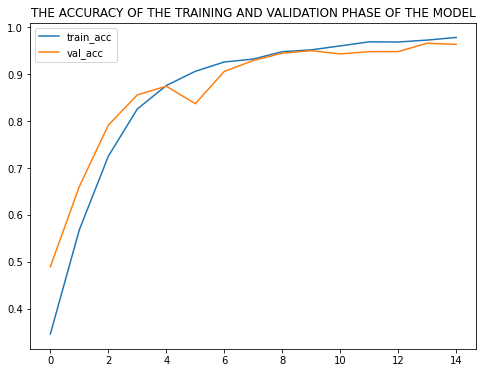

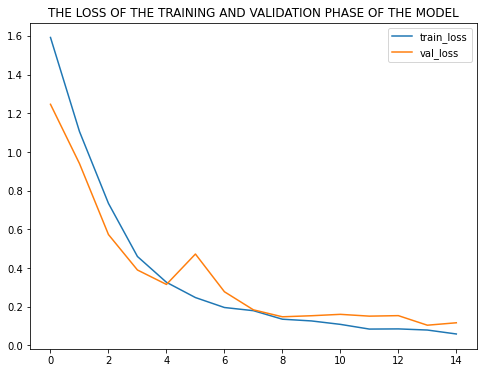

In [ ]:
'''
AFTER TRAINING THE MODEL, WE NOW SEE THE DIFFERENT PERFORMANCE METRICS OF THE MODEL AND HAVE SOME COMPARISION WITH EACH CLASSES
SOME OF THE PERFORMANCE METRICS ARE AS FOLLOWS INCLUDE THIS IN REPORT PRANNETH:

PRECISION
RECALL
F1-SCORES
ACCURACY
ALSO CONFUSION MATRIX AND TOTAL CLASSIFICATION REPORT
ALSO WITH TESTING DATA
'''

ACC = history.history['accuracy']
VAL_ACC = history.history['val_accuracy']

plt.figure(figsize=(8,6))
plt.title("THE ACCURACY OF THE TRAINING AND VALIDATION PHASE OF THE MODEL")
plt.plot(ACC, label = 'train_acc')
plt.plot(VAL_ACC, label = 'val_acc')
plt.legend()

LOSS = history.history['loss']
VAL_LOSS = history.history['val_loss']

plt.figure(figsize=(8,6))
plt.title("THE LOSS OF THE TRAINING AND VALIDATION PHASE OF THE MODEL")
plt.plot(LOSS, label = 'train_loss')
plt.plot(VAL_LOSS, label = 'val_loss')
plt.legend()

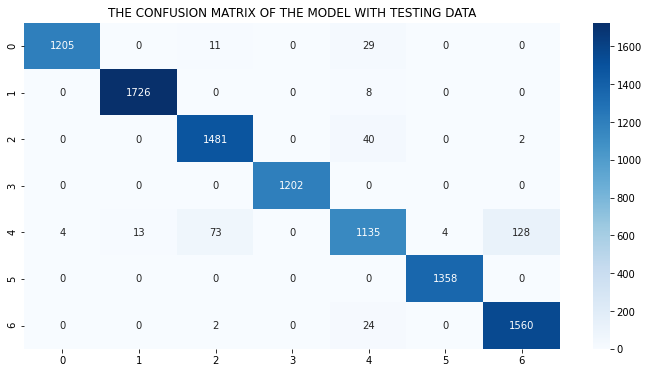

In [ ]:
'''
CONFUSION MATRIX COMPARISIONS OF THE MODEL
CONFUSION MATRIX OF THE MODEL FOR DIFFERENT CLASSES WITH THE TESTING DATA
'''

Y_true = np.array(Y_test)

Y_pred = model.predict(X_test)
Y_pred = np.array(list(map(lambda x: np.argmax(x), Y_pred)))

cm1 = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 6))
plt.title('THE CONFUSION MATRIX OF THE MODEL WITH TESTING DATA')
sns.heatmap(cm1, annot = True, fmt = 'g' ,vmin = 0, cmap = 'Blues')

THE PLOTS TESTING WITH THE MODEL


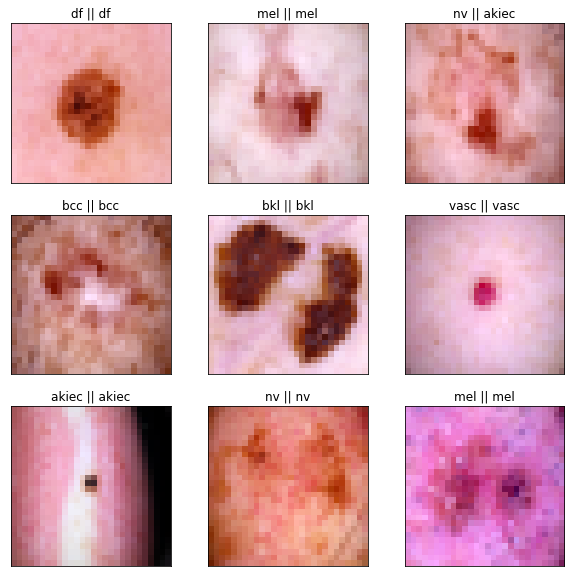

In [ ]:
'''
VISUALISING THE REAL TIME PREDICTIONS WITH THE PLOTS OF THE TEST DATA THE TITLE OF EACH PLOT IS FORMATED AS:

|GROUND TRUTH || PREDICTED VALUE|

ON THE TESTING DATA
'''

def visualisePlots_test(X,Y, model, rows, columns):
    class_dicts = {
        0: 'nv',
        1: 'mel',
        2: 'bkl',
        3: 'bcc',
        4: 'akiec',
        5: 'vasc',
        6: 'df', 
    }
    
    data = []
    target = []
    
    Y_pred = model.predict(X)
    Y_pred = np.array(list(map(lambda x: np.argmax(x), Y_pred)))

    for i in range(rows*columns):
        data.append(X[i])
        target.append(Y[i])

    width = 10
    height = 10
    fig = plt.figure(figsize=(10,10))
    for i in range(columns*rows):
        temp_img = array_to_img(data[i])
        fig.add_subplot(rows, columns, i+1)
        plt.imshow(temp_img)
        plt.xticks([])
        plt.yticks([])
        plt.title(str(class_dicts[target[i][0]]) + " || " + str(class_dicts[Y_pred[i]]))
    plt.show()
    
# USING THE MODELS AND VISUALISING THEM

print('THE PLOTS TESTING WITH THE MODEL')
visualisePlots_test(X_test,Y_test, model, 3, 3) 

In [ ]:
label_mapping = {
    0: 'nv',
    1: 'mel',
    2: 'bkl',
    3: 'bcc',
    4: 'akiec',
    5: 'vasc',
    6: 'df'
}

classification_report_model = classification_report(Y_true, Y_pred, target_names=label_mapping.values())
print(classification_report_model)

              precision    recall  f1-score   support

          nv       1.00      0.97      0.98      1245
         mel       0.99      1.00      0.99      1734
         bkl       0.95      0.97      0.96      1523
         bcc       1.00      1.00      1.00      1202
       akiec       0.92      0.84      0.88      1357
        vasc       1.00      1.00      1.00      1358
          df       0.92      0.98      0.95      1586

    accuracy                           0.97     10005
   macro avg       0.97      0.97      0.97     10005
weighted avg       0.97      0.97      0.97     10005



In [ ]:
# FOR SHOWING TO SIR THAT OUR MODEL IS LIGHT WEIGHT AND THAT IT RUNS ON RPI
time_model = end_model - start_model
print("TIME TAKEN BY MODEL : ", time_model)


model_acc_test = model.evaluate(X_test, Y_test, verbose=0)[1]
print("TEST ACCURACY OF MODEL: {:.3f}%".format(model_acc_test * 100))

TIME TAKEN BY MODEL :  0:01:38.071701
TEST ACCURACY OF MODEL: 96.622%


In [ ]:
from keras.models import load_model
model.save("skinmodel.h5")
loaded_model = load_model("skinmodel.h5")
loss, accuracy = loaded_model.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.1022 - accuracy: 0.9662


In [ ]:
from keras.models import load_model
m = load_model('skinmodel.h5')

In [ ]:
m.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.1022 - accuracy: 0.9662


[0.10216367989778519, 0.9662168622016907]

0: 'nv',
        1: 'mel',
        2: 'bkl',
        3: 'bcc',
        4: 'akiec',
        5: 'vasc',
        6: 'df',

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

mel mel


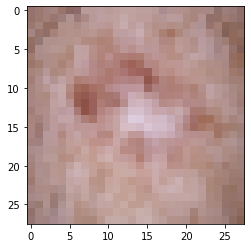

In [ ]:
s=3
img = X_test[s]
plt.imshow(img)
img = np.expand_dims(img, 0)
print(type_cancer[Y_test[s][0]], type_cancer[np.argmax(m.predict(img))])